# Climate Change Portfolio Post

Climate change is impacting the way people live around the world. Higher highs, lower lows, storms, and smoke – we’re all feeling the
effects of climate change. 

Here, we look at trends in temperature over time along the San Pedro River in southeast Arizona. I'm interested in this area because some of my research assesses floodplain organic carbon stocks along this river. The data we use in this analysis was collected at a station right next to the San Pedro River. 

Southeast Arizona has an arid climate and has been experiencing an extended drought (Archer & Predick, 2008). I'm interested in seeing whether there is a significant trend in temperature over the last few decades in this region near my study site.

In the field, we saw that many riparian areas that had been altered by human activities had depleted ground water levels, reduced presence of large native vegetation, and in some places, the channel had completely dried up (Haney, 2005). I would hypothesize that there was also an increase in mean annual temperatures in this region over the last few decades, which may have exacerbated some of these changes that we observed.

<div>
<center><img src="IMG_1326.jpeg" height="450"/></center>
</div>

<div align="center">
Field work photo from a completely dry section of the San Pedro River during May of 2025
</div>

### Load Python packages

In [1]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd ### analyze and manipulate data

import matplotlib.pyplot as plt ### advanced options on matplotlib/seaborn/pandas plots
import seaborn as sns ### common statistical plots for tabular data
from sklearn.linear_model import LinearRegression ### fit an OLS linear regression
import geopandas as gpd ### Work with vector data
from osmnx import features as osm ### Search for locations by name

from bokeh.core.validation import silence ### silencing warnings associated with interactive maps
from bokeh.core.validation.warnings import FIXED_SIZING_MODE ### specify warnings

### For some geographical context, I'll first create an interactive map of the study area.

In [2]:
# Search for San Pedro River, AZ on open street map
sanpedroriver_gdf = osm.features_from_address(
    'San Pedro River, Arizona, United States',
    {'waterway': ['river']},
    dist=1)

In [3]:
### troubleshooting workaround for interactive plot
hvplot.extension("bokeh")

### silence warning for sizing parameter
silence(FIXED_SIZING_MODE, True)

# Plot river boundary
san_pedro_river_map = sanpedroriver_gdf.hvplot(
    # Givethe map a descriptive title
    title="San Pedro River, Arizona, U.S.",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    #fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web
hv.save(san_pedro_river_map, 'san-pedro-river.html')

# Display the map
san_pedro_river_map

:Overlay
   .WMTS.I :WMTS   [Longitude,Latitude]
   .Path.I :Path   [Longitude,Latitude]

** This is a map of part of the San Pedro River in southeast Arizona. This is an important area to study because the river is one of the last undammed rivers in the Southwest U.S. and is a major tributary of the Gila River. The data we're using comes from a station nearby. **

### Download the data

I've downloaded some climate data from NCEI for the Muleshoe Ranch Station in Southeast Arizona in CSV format (https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USR0000AMUL/detail). This station has one of the longer temperature datasets of the stations located by the San Pedro River.

In [4]:
### import data as df
arizona_df = pd.read_csv('muleshoe_ranch_climate_data.csv',

    ### Tell python which column to use as the index
    index_col='DATE',

    ### Tell python to treat the DATE as a date
    parse_dates=True,

    ### Designate NaNs as missing data
    na_values=["NaN"]
)

### Clean up the DataFrame

In [5]:
### create new df that only includes temperature column
az_temp_df = arizona_df[['TAVG']]

### Convert the units

Here we'll make sure we're using the right units by converting from F to C using a unit conversion function.

In [6]:
### rename temperature column to include units
temp_units_df = az_temp_df.rename(columns={
    'TAVG': 'temp_f',
})

### create function to convert units from f to c
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f - 32)*5/9

### convert temp data from f to c
temp_units_df['temp_c'] = (
    temp_units_df['temp_f'].apply(convert_f_to_c))

### Plot the temperature data

Next we'll plot all of the daily temperature data. This will show us whether there are any gaps in the data or any measurements that look incorrect. 

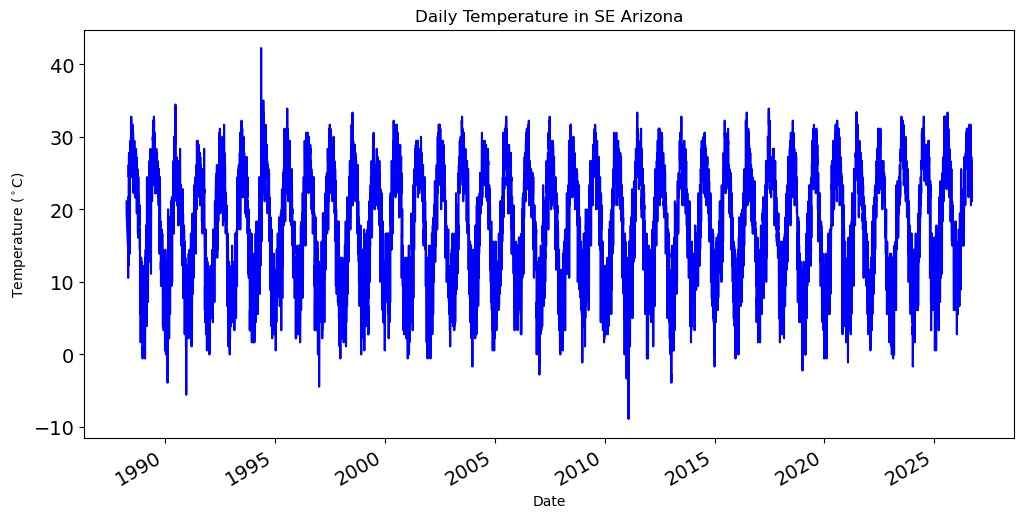

In [7]:
### plot without the legend
no_legend = temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in SE Arizona',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    ### increase fig size
    figsize = (12, 6),
    ### increase font size
    fontsize = 14,
    ### change color
    color = 'blue') 

no_legend.legend().remove()

> We see that the range of data values looks relatively consistent and there are no gaps in measurements. 

### Clean up time series plots by resampling

Now we'll resample the data. This summarizes the data as an annual mean value, giving us one data point per year.

In [8]:
### resample to mean annual temps
annual_temp_df = (

    ### resample df
    temp_units_df

    ### sample annually
    .resample('YS')

    ### calculate mean
    .mean()
)

### Plot the annual data

<Axes: title={'center': 'Mean Annual Temperature in SE Arizona'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

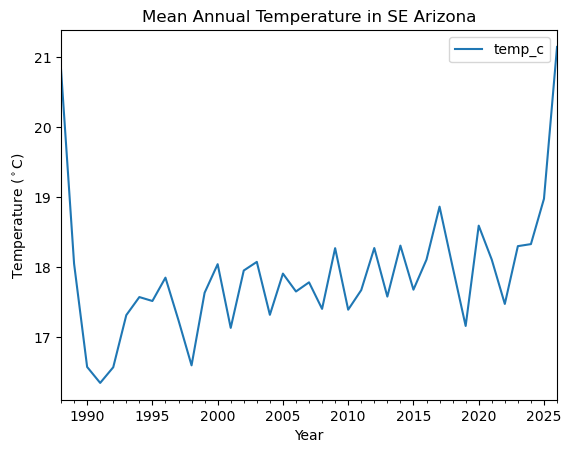

In [9]:
annual_temp_df.plot(y = 'temp_c',
                  title = 'Mean Annual Temperature in SE Arizona',
                  xlabel = 'Year',
                  ylabel = 'Temperature ($^\circ$C)')

>**Plot Interpretations**
>* We see that in the first and last year of data, the plotted mean annual temperature is extremely high compared to other years. This is caused by incomplete data. 2026 isn't over yet, and data from 1988 starts in April, so it would be a good idea to remove these years.
>* Mean annual temperatures are lower in the 1990s than they are in the 2020s. While this isn't a particularly long study period, this trend in 35+ years of data could be a result of climate change. It is difficult to say that conclusively without further analysis/looking at the data more closely.

### Make an interactive plot

In [10]:
### subset data to only include temp in Celsius
annual_temp_c_df = annual_temp_df[['temp_c']]

### subset data to 1988-2025 because 2026 isn't a full year of data
complete_data_df = annual_temp_c_df.loc['1989':'2025']

In [11]:
### plot the annual data interactively
annual_temp_plot = complete_data_df.hvplot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in SE Arizona',
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

annual_temp_plot

:Curve   [DATE]   (temp_c)

>**Data Exploration**
>
>When we remove years with incomplete data:
>* The minimum mean annual temperature is 16.341 degrees C in 1991
>* The maximum mean annual temperature is 18.974 degrees C in 2025

### Quantify how fast the climate is changing with a trend line

In [12]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = complete_data_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = complete_data_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.03525516] degrees per year


> The slope of the linear regression shows us that temperatures have increased by 0.035 degrees C per year during this study period.

### Plot the trend line

Trend lines help us understand and process a time-series plot. In this case, we’ve chosen mean temperature values
rather than extremes, so we think OLS is an appropriate model to use to show a trend.

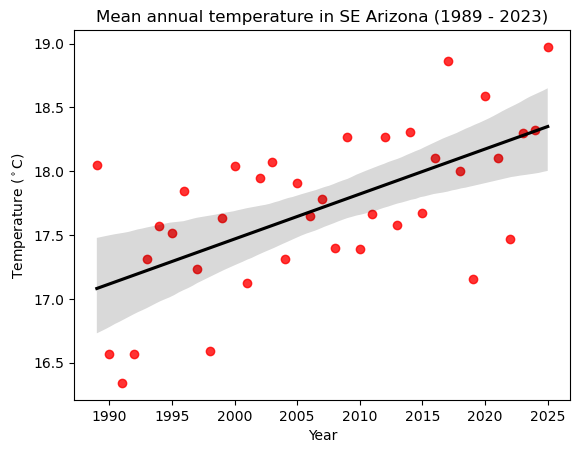

In [13]:
### plot data
ax = sns.regplot(
    x = complete_data_df.index.year, 
    y = complete_data_df.temp_c,

    ### change the color of data points
    color = 'red',

    ### change the color of the trendline
    line_kws= {'color': 'black'}
)

### make labels
ax.set(
    title = 'Mean annual temperature in SE Arizona (1989 - 2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/climate-change/arizona-climate-trendline.jpeg')

### plot it
plt.show()

>**Takeaway: Mean annual temperatures in Boulder, CO have increased over the last century*

>In SE Arizona, mean annual temperatures have increased by 0.035 degrees C per year from 1989 to 2025. During this time, annual temperatures have increased by more than 1 degree C since 1989. These increasing temperature trends are likely a result of climate change, although other environmental characteristics, like trends in sea surface temperatures, may also influence some of this rate of temperature change. 

>Arid region river corridors are hotspots of carbon storage, which can be limited by water availability (Sutfin et al., 2016). Higher temperatures can affect the water availability in systems like the San Pedro River, and the combined effects of long term drought and increasing mean annual temperatures ultimately have a significant effect on the physical characteristics of riparian corridors in this region.

### Bibliography
* S. R. Archer & K. I. Predick. 2008. Climate change and ecosystems of the southwestern United States. https://cales.arizona.edu/research/archer/publications/refereed_journal_articles/Archer-Predick_2008_Rangelands.pdf
* J. Haney. 2005. The lower San Pedro River: hydrology and flow restoration for biodiversity conservation. https://research.fs.usda.gov/treesearch/23220
* Sutfin, N., Wohl, E., Dwire, K. 2016. Banking carbon: A review of organic carbon storage and physical factors influencing retention in floodplains and riparian ecosystems. https://doi.org/10.1002/esp.3857